In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO

# Load your HTML file
with open('../../../Sensitive Coding/blizzard/blizzard_data.html', 'r', encoding='utf-8') as f:
    html = f.read()

# Parse with BeautifulSoup
soup = BeautifulSoup(html, 'html.parser')

# Process headers and tables
tables_with_headers = []
elements = soup.find_all(['h2', 'table'])

current_header = None

for el in elements:
    if el.name == 'h2':
        current_header = el.get_text(strip=True)
    elif el.name == 'table':
        # Wrap HTML string in StringIO to avoid the FutureWarning
        table_html = str(el)
        df = pd.read_html(StringIO(table_html))[0]
        tables_with_headers.append((current_header, df))

In [3]:
#Hiding output so sensitive information not shown

# # Display result
# for idx, (header, df) in enumerate(tables_with_headers):
#     if "Player" or "Hero" in header:
#         print(f"\n--- Table {idx+1} ---")
#         print(f"Header: {header}")
#         print(df.head())

* Looking at the HTML file, the only tables we want for now are 47, 48, and 50

## Maps

In [4]:
maps = tables_with_headers[47]
maps

('Player Map Stat',
      Stat Context Type                 Stat Context Name               Map  \
 0             UNRANKED                               NaN  Temple of Anubis   
 1             UNRANKED                               NaN  Temple of Anubis   
 2             UNRANKED                               NaN  Temple of Anubis   
 3             UNRANKED                               NaN  Temple of Anubis   
 4             UNRANKED                               NaN        King's Row   
 ...                ...                               ...               ...   
 1629           RULESET  Stadium - OW2 Ranked - Season 02  Throne of Anubis   
 1630           RULESET  Stadium - OW2 Ranked - Season 02           Hanaoka   
 1631           RULESET  Stadium - OW2 Ranked - Season 02           Hanaoka   
 1632           RULESET  Stadium - OW2 Ranked - Season 02          Colosseo   
 1633           RULESET  Stadium - OW2 Ranked - Season 02          Colosseo   
 
                              

In [5]:
maps = pd.DataFrame(maps[1])

In [6]:
maps.head(15)

,Stat Context Type,Stat Context Name,Map,Stat,Amount
0,UNRANKED,NaN,Temple of Anubis,Map Rpl {0}:Win:Wins;,1.0
1,UNRANKED,NaN,Temple of Anubis,Map Rpl {0}:Enter:Enters;,1.0
2,UNRANKED,NaN,Temple of Anubis,Offense Rpl {0}:Win:Wins;,1.0
3,UNRANKED,NaN,Temple of Anubis,Offense Rpl {0}:Enter:Enters;,1.0
4,UNRANKED,NaN,King's Row,Map Rpl {0}:Win:Wins;,15.0
5,UNRANKED,NaN,King's Row,Map Rpl {0}:Enter:Enters;,28.0
6,UNRANKED,NaN,King's Row,Offense Rpl {0}:Win:Wins;,10.0
7,UNRANKED,NaN,King's Row,Offense Rpl {0}:Enter:Enters;,14.0
8,UNRANKED,NaN,King's Row,Defense Rpl {0}:Win:Wins;,5.0
9,UNRANKED,NaN,King's Row,Defense Rpl {0}:Enter:Enters;,14.0


In [7]:
# Sample: filter categorical columns (object or category)
categorical_cols = maps.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    unique_vals = maps[col].unique()
    print(f"\nColumn: {col}")
    print(unique_vals)


Column: Stat Context Type
['UNRANKED' 'VS_AI' 'RULESET']

Column: Stat Context Name
[nan 'Elimination' 'Mystery Heroes' 'Team Deathmatch' 'Deathmatch'
 'Halloween' 'No Limits' 'LucioBaller' 'OW2 Ranked - Season 01'
 'OW2 Ranked - Season 01 OpenQueue' 'Quick Play Open Queue' 'Junkenstein2'
 'OW2 Ranked - Season 02 OpenQueue' 'OW2 Ranked - Season 02'
 'OW2 Ranked - Season 03' 'OW2 Ranked - Season 03 OpenQueue'
 'OlympusDeathmatch' 'OW2 Ranked - Season 04'
 'OW2 Ranked - Season 04 OpenQueue' 'Hero Mastery - Easy'
 'OW2 Ranked - Season 05' 'GreaterRift' 'VolleyBall'
 'Hero Mastery - Medium' 'Prop Hunt' 'OW2 Ranked - Season 06'
 'OW2 Ranked - Season 07' 'Event Mission - London Fog'
 'OW2 Ranked - Season 08' 'OW2 Ranked - Season 09'
 'Extraction - Antarctica' 'OW2 Ranked - Season 10'
 'OW2 Ranked - Season 11' 'OW2 Ranked - Season 11 OpenQueue'
 'OW2 Ranked - Season 12' 'OW2 Ranked - Season 13'
 'OW2 Ranked - Season 13 OpenQueue' 'Stadium - OW2 Ranked - Season 01'
 'OW2 Ranked - Season 14' '

In [8]:
#Filtering to records where Stat Context Name only has ranked values in it
maps = maps[maps['Stat Context Name'].str.contains('OW2 Ranked', case=False, na=False)]
maps = maps[~maps['Stat Context Name'].str.contains('Stadium|Open', case=False, na=False)]

In [9]:
maps.drop('Stat Context Type', axis=1, inplace=True)

In [10]:
# Step 1: Extract the stat type (e.g., Enter, Win, Tie) from the Stat column
maps['Stat_Type'] = maps['Stat'].str.extract(r':(\w+):')

# Step 2: Pivot the table using groupby + pivot
maps_wide = maps.pivot_table(
    index=['Stat Context Name', 'Map'],
    columns='Stat_Type',
    values='Amount',
    aggfunc='sum'  # In case multiple rows exist for the same stat
).reset_index()

In [11]:
maps_wide.fillna(0, inplace=True)
maps = maps_wide.copy(deep=True)

In [12]:
maps.head()

Stat_Type,Stat Context Name,Map,Enter,Tie,Win
0,OW2 Ranked - Season 01,Busan,1.0,0.0,0.0
1,OW2 Ranked - Season 01,Circuit royal,1.0,0.0,1.0
2,OW2 Ranked - Season 01,Dorado,1.0,0.0,0.0
3,OW2 Ranked - Season 01,Nepal,1.0,0.0,1.0
4,OW2 Ranked - Season 01,Paraíso,1.0,0.0,0.0


In [13]:
maps['Loss'] = (maps['Enter'] - (maps['Tie'] + maps['Win']))
maps.head()

Stat_Type,Stat Context Name,Map,Enter,Tie,Win,Loss
0,OW2 Ranked - Season 01,Busan,1.0,0.0,0.0,1.0
1,OW2 Ranked - Season 01,Circuit royal,1.0,0.0,1.0,0.0
2,OW2 Ranked - Season 01,Dorado,1.0,0.0,0.0,1.0
3,OW2 Ranked - Season 01,Nepal,1.0,0.0,1.0,0.0
4,OW2 Ranked - Season 01,Paraíso,1.0,0.0,0.0,1.0


In [14]:
maps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Stat Context Name  427 non-null    object 
 1   Map                427 non-null    object 
 2   Enter              427 non-null    float64
 3   Tie                427 non-null    float64
 4   Win                427 non-null    float64
 5   Loss               427 non-null    float64
dtypes: float64(4), object(2)
memory usage: 20.1+ KB


In [15]:
maps.describe()

Stat_Type,Enter,Tie,Win,Loss
count,427.000000,427.000000,427.000000,427.000000
mean,7.922717,0.274005,3.943794,3.704918
std,4.310281,0.528399,2.574090,2.419997
min,1.000000,0.000000,0.000000,0.000000
25%,4.000000,0.000000,2.000000,2.000000
50%,7.000000,0.000000,4.000000,3.000000
75%,11.000000,0.000000,5.000000,5.000000
max,25.000000,3.000000,12.000000,12.000000


In [16]:
maps.rename(columns={'Tie': 'Draw'}, inplace=True)

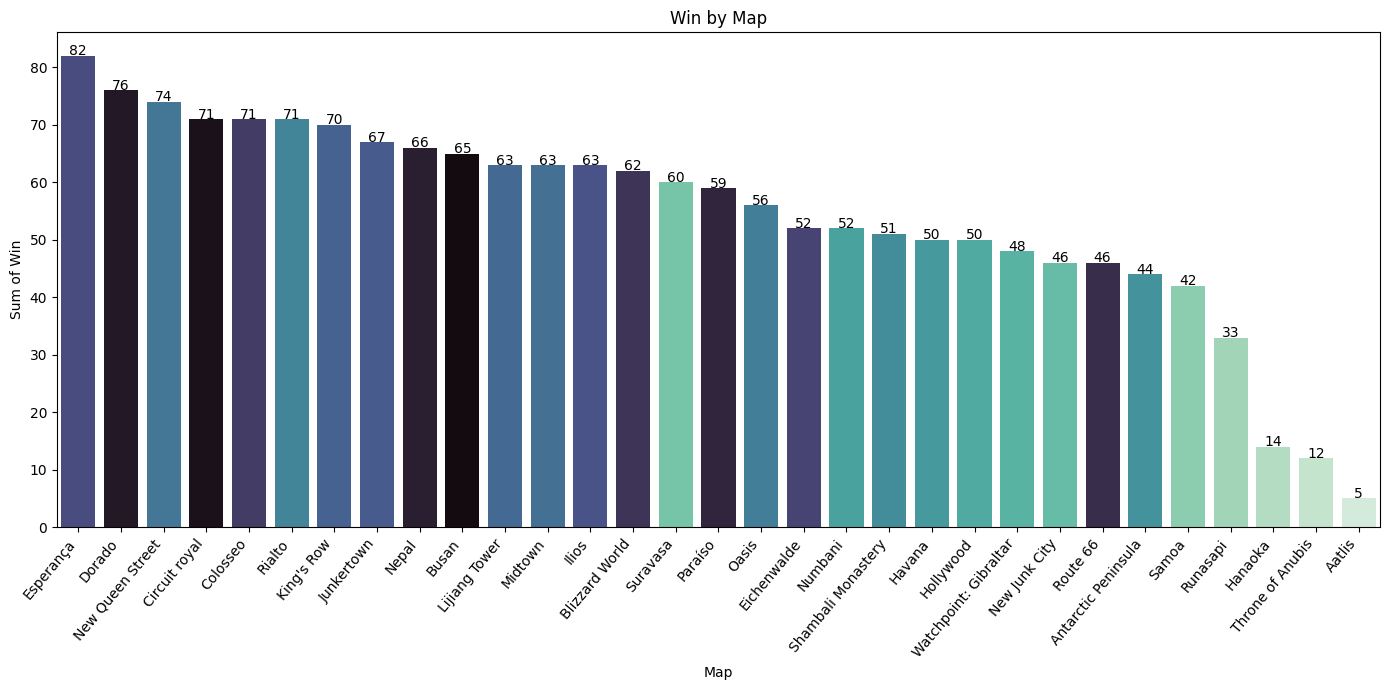

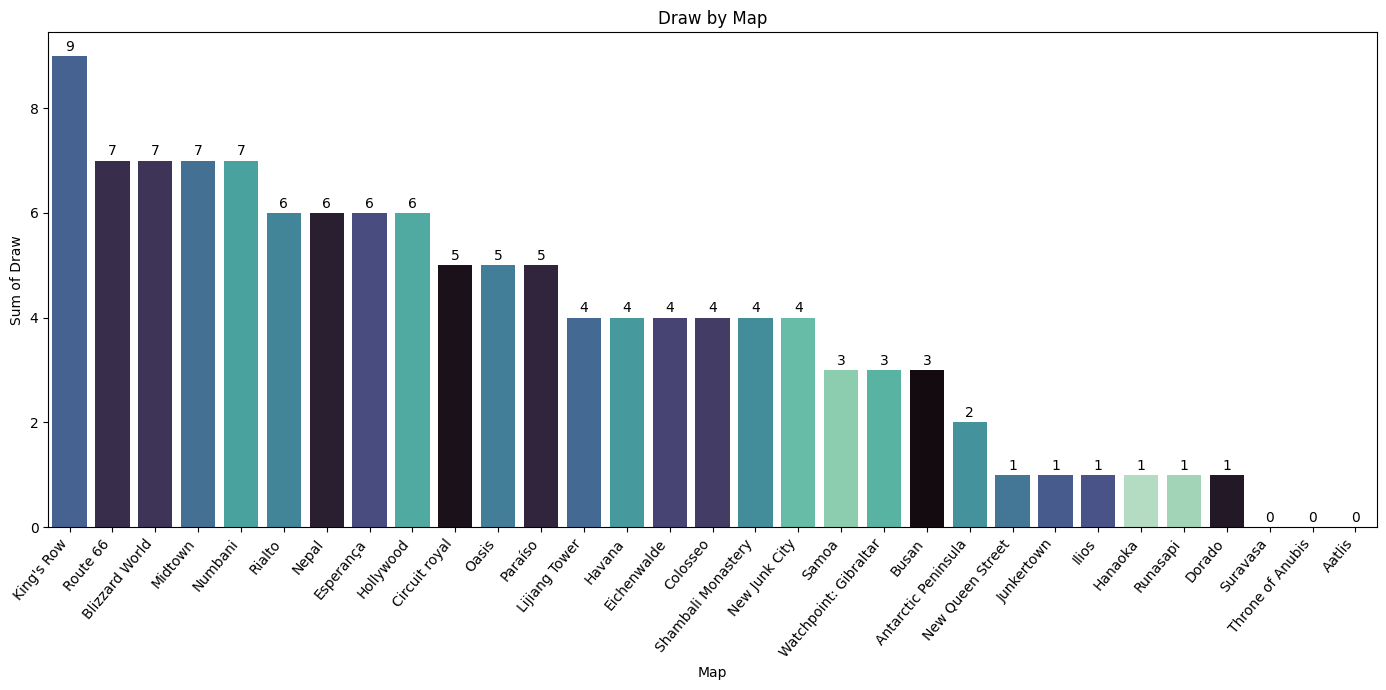

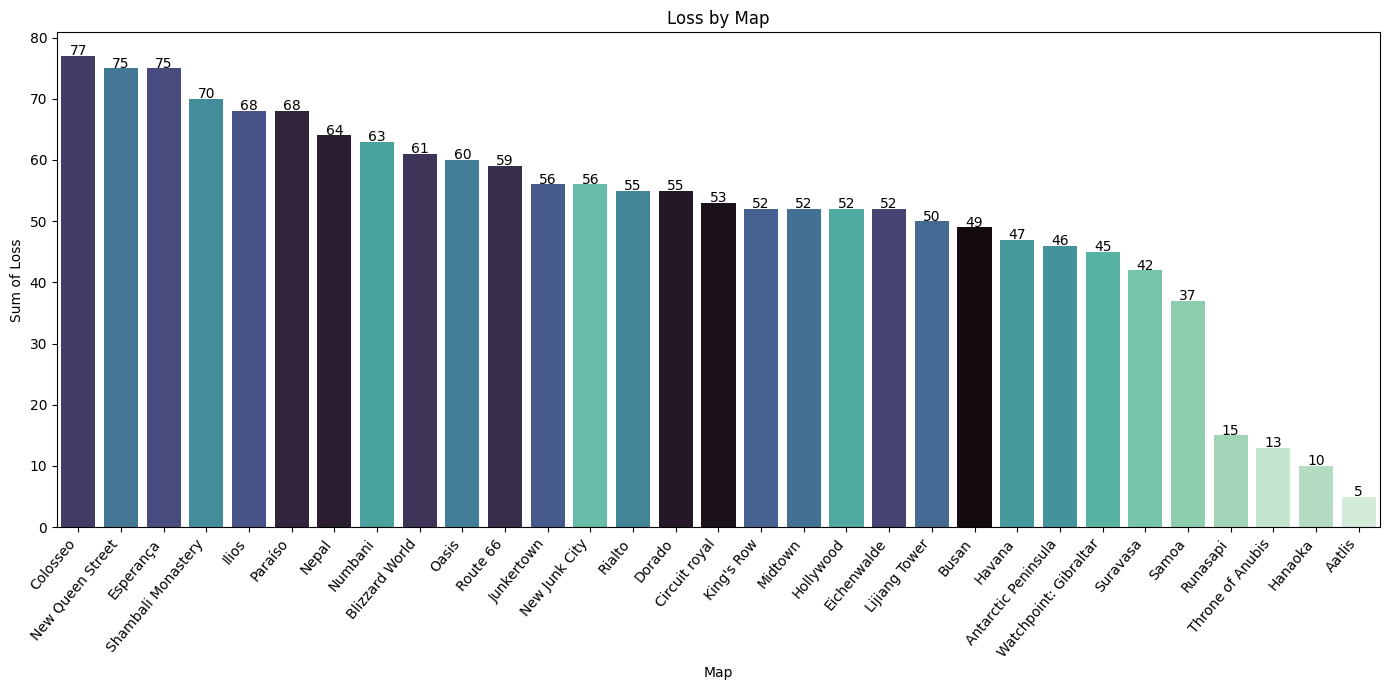

In [17]:
clist = ['Win', 'Draw', 'Loss']

for column in clist:
    
    #Create new figure for each column
    plt.figure(figsize=(14, 7)) 
    
    #Grouping by totals for custom ordering in graphs below
    order = maps.groupby('Map')[column].sum().sort_values(ascending=False).index
    
    ax = sns.barplot(data=maps, x='Map', y=column, hue='Map', palette='mako', estimator=sum, errorbar=None, order=order)

    # Annotate each bar with its height value above the bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,  # X coordinate: center of the bar
            height + 0.1,                    # Y coordinate: a bit above the bar
            f'{height:.0f}',                 # Text to display (formatted as int)
            ha='center'                      # Center alignment horizontally
        )
        
    plt.xticks(rotation=50, ha='right')
    plt.title(f'Total {column} per Map')
    plt.ylabel(f'Sum of {column}')
    plt.title(f'{column} by Map')
    plt.tight_layout()

## Player Hero Stat - All

In [18]:
player_all = tables_with_headers[48]

## Player Hero Stat - ???

In [19]:
player_small = tables_with_headers[50]